# **Base de Dados Câncer de Mama Wisconsin**

Notebook de análise exploratória e classificação binária da base WDBC.

**Objetivo:** identificar tumores benignos (0) e malignos (1) a partir de características morfológicas de núcleos celulares obtidas por FNA (*Fine Needle Aspiration*).

**Estrutura do notebook:**
1. Configuração inicial
2. Funções auxiliares para gráficos e métricas
3. Carregamento e preparação da base de dados
4. Análise exploratória (EDA)
5. Árvore de Decisão — baseline
6. K-Nearest Neighbors (KNN)
7. Regressão Logística
8. Random Forest
9. SVM
10. Visualização de estrutura: UMAP e PCA
11. Interpretabilidade do modelo com SHAP
12. Exportação dos modelos

> **Pré-requisitos:** Python 3.11 ou 3.12 com as dependências do `requirements.txt`.
> Consulte o `README.md` na raiz do repositório para o guia de instalação completo.

In [1]:
import sys

# Valida que o ambiente usa Python 3.11 ou superior
major, minor = sys.version_info.major, sys.version_info.minor
versao_atual = f"{major}.{minor}.{sys.version_info.micro}"

if (major, minor) < (3, 11):
    print(f"⚠️  Python {versao_atual} detectado.")
    print("   Este projeto requer Python 3.11 ou superior.")
    print("   Consulte o README.md para instruções de instalação.")
else:
    print(f"✅ Python {versao_atual} — ambiente compatível.")

✅ Python 3.12.3 — ambiente compatível.


## **1. Configuração Inicial**

> **Dependências:** instale o ambiente virtual e as bibliotecas antes de rodar este notebook.
> ```bash
> python3 -m venv .venv && source .venv/bin/activate
> pip install -r requirements.txt
> ```

In [2]:
# --- Bibliotecas padrão ---
import pickle
import os

import numpy as np
import pandas as pd
from IPython.display import display

# --- Visualização ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Pré-processamento e divisão de dados ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Modelos de Machine Learning ---
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# --- Métricas de avaliação ---
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
)

# --- Redução de dimensionalidade não-linear ---
import umap

# --- Interpretabilidade do modelo ---
import shap

# --- Configurações visuais globais ---
sns.set_theme(style='whitegrid', context='notebook')

# --- Reprodutibilidade ---
# Semente global: garante que splits, treinos e projeções UMAP gerem resultados idênticos a cada execução
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

/home/gabast/vscode/DiagnosisXAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Funções Auxiliares para Gráficos e Métricas

In [3]:
def plot_roc_pr(y_true, y_prob, titulo_prefixo=''):
    """
    Plota as curvas ROC e PR (Precisão-Revocação) lado a lado.

    Parâmetros
    ----------
    y_true        : array-like — rótulos reais (0 ou 1)
    y_prob        : array-like — probabilidades previstas para a classe positiva
    titulo_prefixo: str        — prefixo opcional para o título dos gráficos
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Curva ROC
    axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
    axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Aleatório')
    axes[0].set(
        title=f'{titulo_prefixo}Curva ROC',
        xlabel='Falso Positivo (1 - Especificidade)',
        ylabel='Verdadeiro Positivo (Sensibilidade)',
    )
    axes[0].legend(loc='lower right')

    # Curva Precisão-Revocação
    axes[1].plot(rec, prec, color='darkorange', label=f'PR-AUC = {pr_auc:.3f}')
    axes[1].set(
        title=f'{titulo_prefixo}Curva Precisão-Revocação',
        xlabel='Revocação',
        ylabel='Precisão',
    )
    axes[1].legend(loc='lower left')

    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, labels=('Benigno', 'Maligno'), titulo='Matriz de Confusão'):
    """
    Exibe a Matriz de Confusão como heatmap anotado.

    Parâmetros
    ----------
    y_true : array-like — rótulos reais
    y_pred : array-like — rótulos previstos
    labels : tuple     — nomes das classes (negativa, positiva)
    titulo : str       — título do gráfico
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=[f'Real {labels[0]}', f'Real {labels[1]}'],
        columns=[f'Pred. {labels[0]}', f'Pred. {labels[1]}'],
    )
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(titulo)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def compute_stats(y_true, y_pred, y_prob):
    """
    Calcula métricas consolidadas de classificação binária.

    Retorna um dict com: Acurácia, Sensibilidade, Especificidade, F1, ROC-AUC e PR-AUC.

    Parâmetros
    ----------
    y_true : array-like — rótulos reais
    y_pred : array-like — rótulos previstos
    y_prob : array-like — probabilidades para a classe positiva
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc  = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn) if (tp + fn) > 0 else float('nan')   # Recall da classe positiva
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')   # Recall da classe negativa
    f1   = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else float('nan')
    roc  = roc_auc_score(y_true, y_prob)
    pr   = average_precision_score(y_true, y_prob)

    return {
        'Accuracy'             : acc,
        'Sensitivity (Recall+)': sens,
        'Specificity (Recall-)': spec,
        'F1'                   : f1,
        'ROC-AUC'              : roc,
        'PR-AUC'               : pr,
    }

## 3. Carregamento e Preparação da Base de Dados

In [4]:
# --- Carregamento da base de dados local ---
wisconsin_base = pd.read_csv('../data/data.csv')

# --- Limpeza de colunas não preditivas ---
# 'id': identificador do paciente (sem valor preditivo)
# 'Unnamed: 32': coluna vazia gerada na exportação do CSV
wisconsin_base = wisconsin_base.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# --- Codificação do rótulo: 'B' (Benigno) → 0 | 'M' (Maligno) → 1 ---
wisconsin_base['diagnosis'] = wisconsin_base['diagnosis'].map({'B': 0, 'M': 1})

# --- Separação entre atributos (X) e variável alvo (y) ---
X = wisconsin_base.drop(columns=['diagnosis'])
y = wisconsin_base['diagnosis']

feature_names = X.columns.tolist()
target_names  = ['Benigno', 'Maligno']   # índice 0 = Benigno, 1 = Maligno

print(f'Dimensões de X: {X.shape}')
print(f'Distribuição de classes:\n{y.value_counts().rename({0: "Benigno", 1: "Maligno"})}')

# --- Split estratificado (75 % treino | 25 % teste) ---
# stratify=y: mantém a proporção original de classes em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# --- Padronização Z-score (ajustada apenas no treino para evitar data leakage) ---
# Necessária para: Regressão Logística, SVM, PCA, UMAP
scaler         = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_scaled_all   = scaler.transform(X)   # Base completa — usada nas visualizações e SHAP

# Caminhos de saída (referenciados novamente na Seção 13)
caminho_pasta   = '../data'
caminho_arquivo = f'{caminho_pasta}/wisconsin.pkl'
os.makedirs(caminho_pasta, exist_ok=True)

# --- Exportação dos conjuntos para CSV (para facilitar testes no App) ---
treino_df_com = X_train.copy(); treino_df_com['diagnosis'] = y_train
teste_df_com  = X_test.copy();  teste_df_com['diagnosis']  = y_test

treino_df_com.to_csv('../data/dataTreinamento_com_diagnostico.csv', index=False)
teste_df_com.to_csv('../data/dataTeste_com_diagnostico.csv', index=False)
X_train.to_csv('../data/dataTreinamento_sem_diagnostico.csv', index=False)
X_test.to_csv('../data/dataTeste_sem_diagnostico.csv', index=False)

print(f'\nConjuntos criados  →  Treino: {X_train.shape} | Teste: {X_test.shape}')
print("4 arquivos CSV gerados na pasta 'data'.")

Dimensões de X: (569, 30)
Distribuição de classes:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64

Conjuntos criados  →  Treino: (426, 30) | Teste: (143, 30)
4 arquivos CSV gerados na pasta 'data'.


## 4. Análise Exploratória dos Dados (EDA)

### 4.1 Estatísticas Descritivas

In [5]:
# Visão geral do DataFrame: tipos, contagens de não-nulos e uso de memória
wisconsin_base.info()

# Estatísticas descritivas: média, desvio padrão, quartis, mínimo e máximo
wisconsin_base.describe()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 4.2 Distribuição das Classes

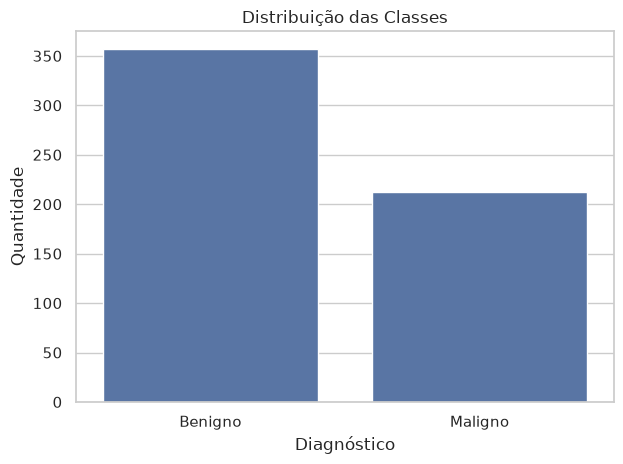

In [6]:
# Contagem de amostras por classe (Benigno = 0, Maligno = 1)
sns.countplot(x='diagnosis', data=wisconsin_base)
plt.title('Distribuição das Classes')
plt.xticks([0, 1], target_names)
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

### 4.3 Histogramas dos Atributos

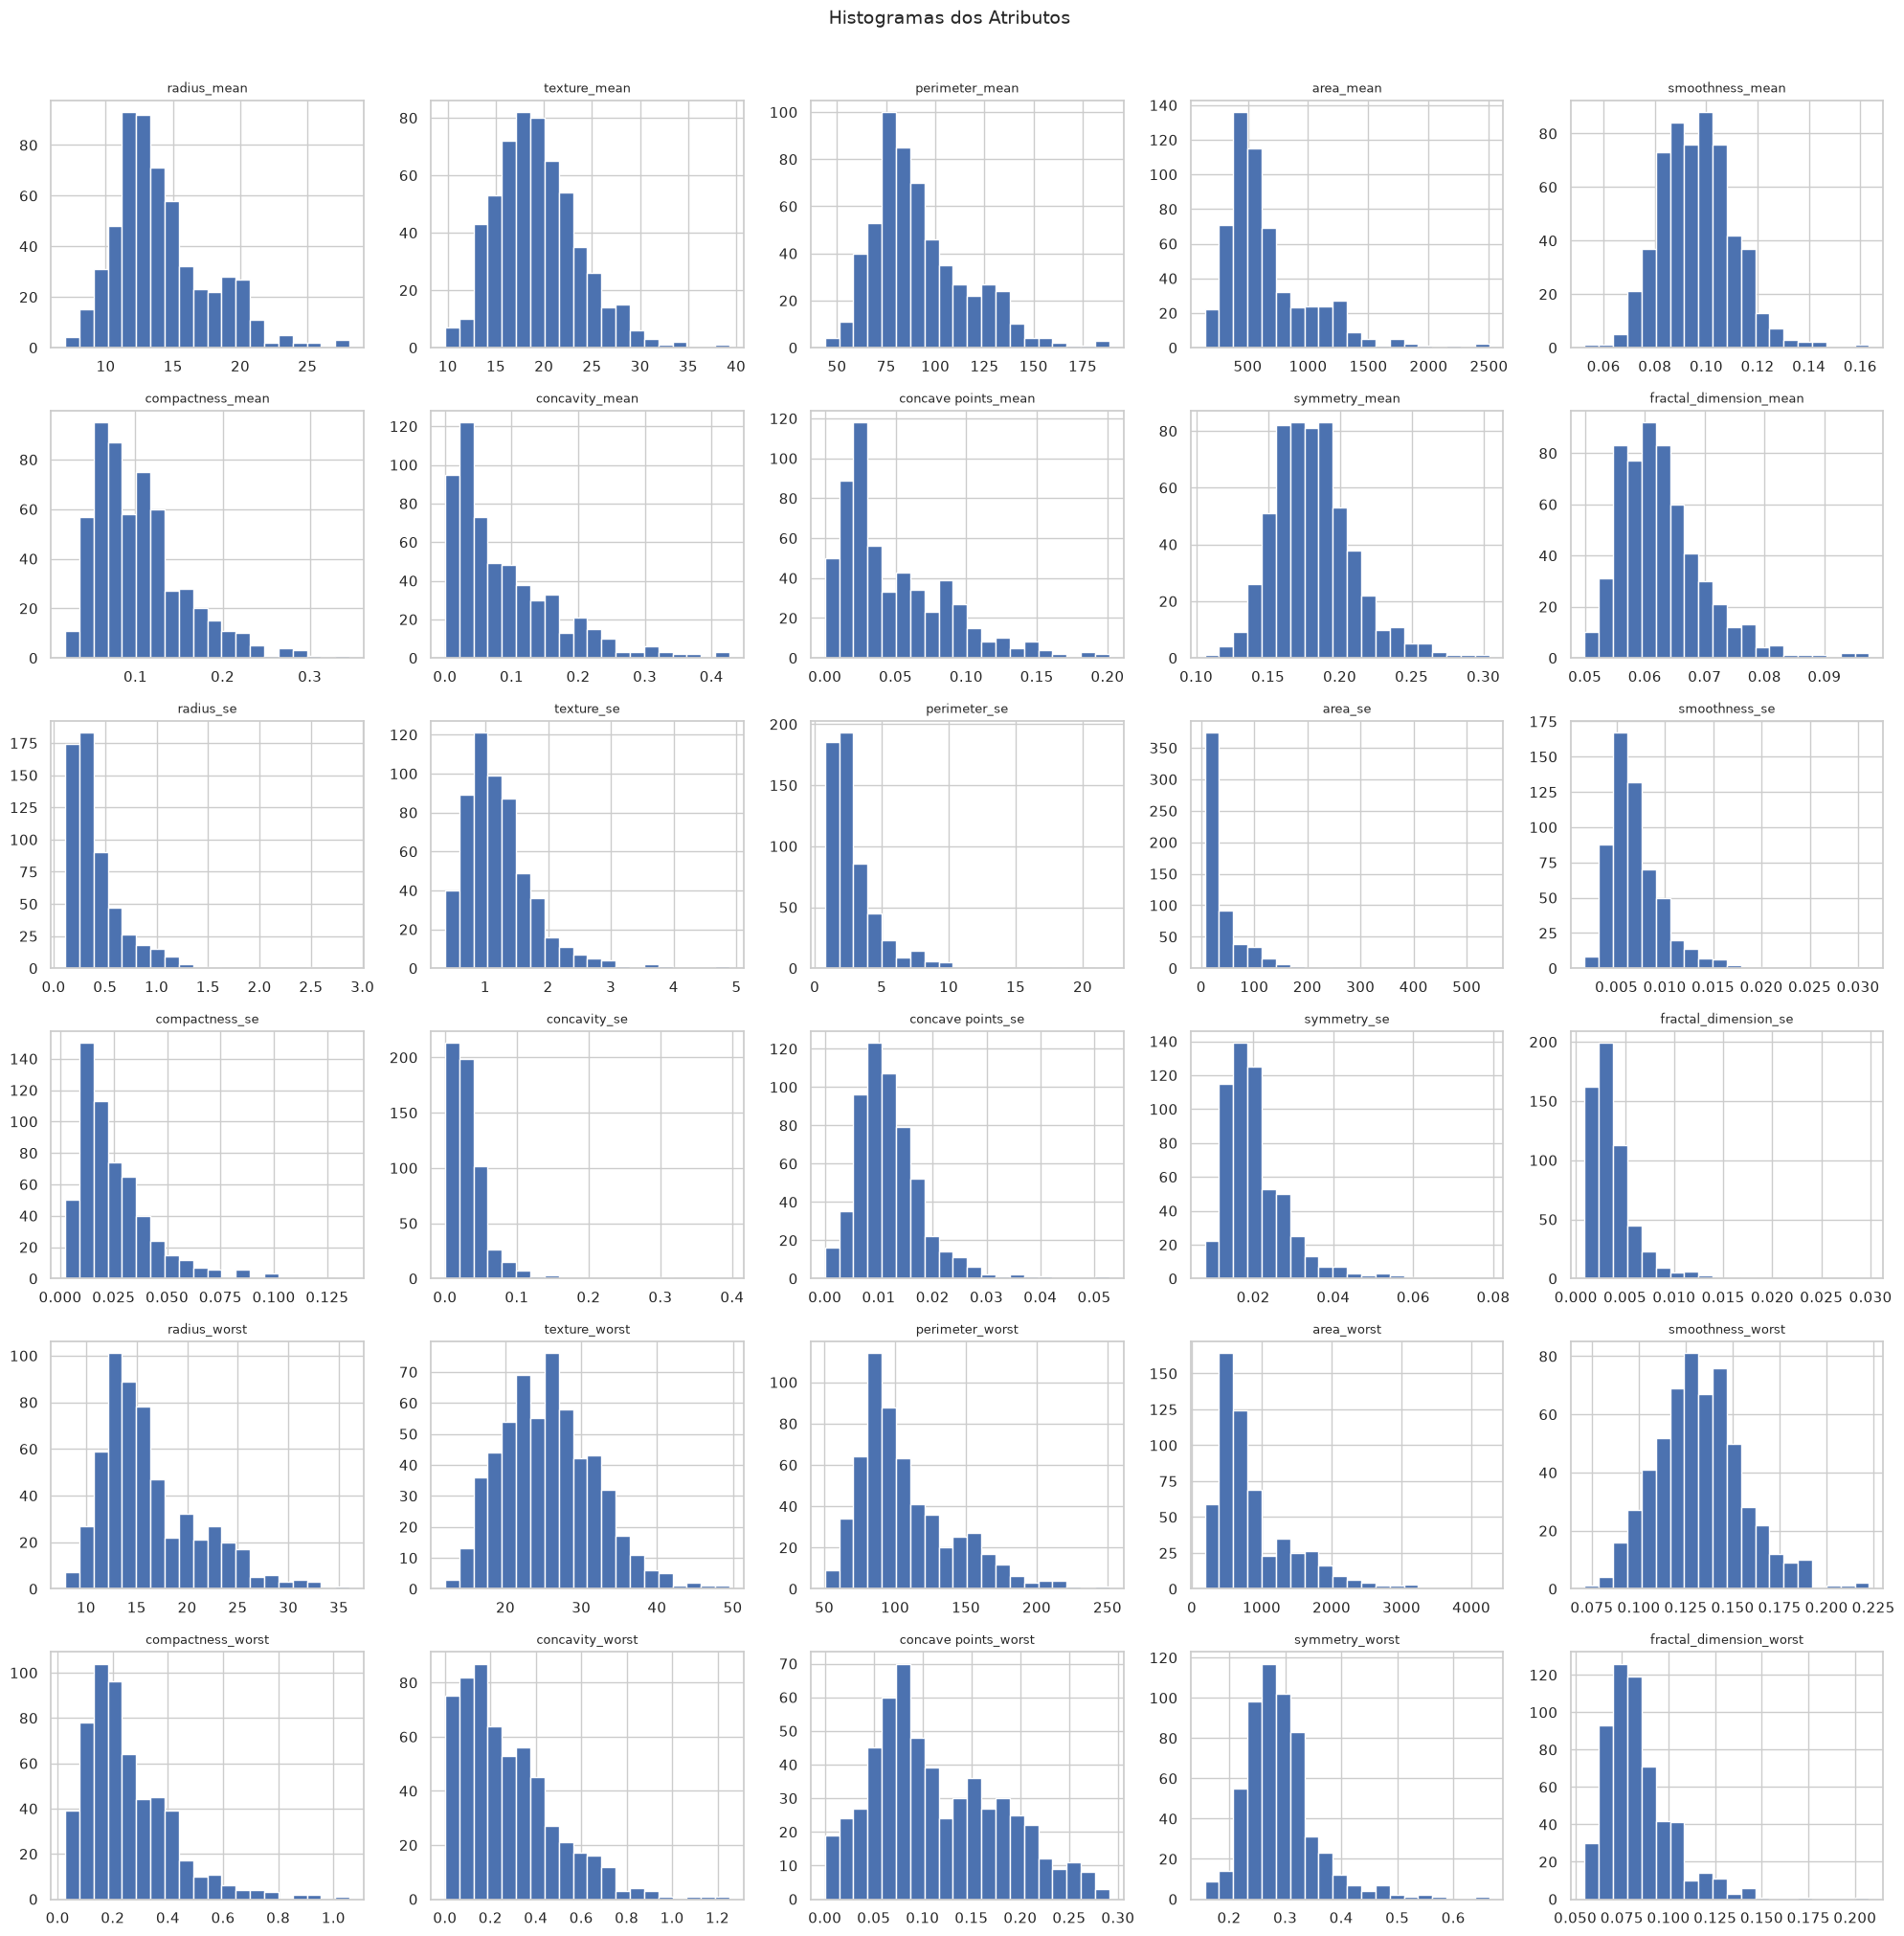

In [7]:
# Histograma de cada um dos 30 atributos numéricos
cols = wisconsin_base.columns[1:31]

fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(wisconsin_base[col], bins=20)
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Histogramas dos Atributos', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 Boxplots dos Atributos

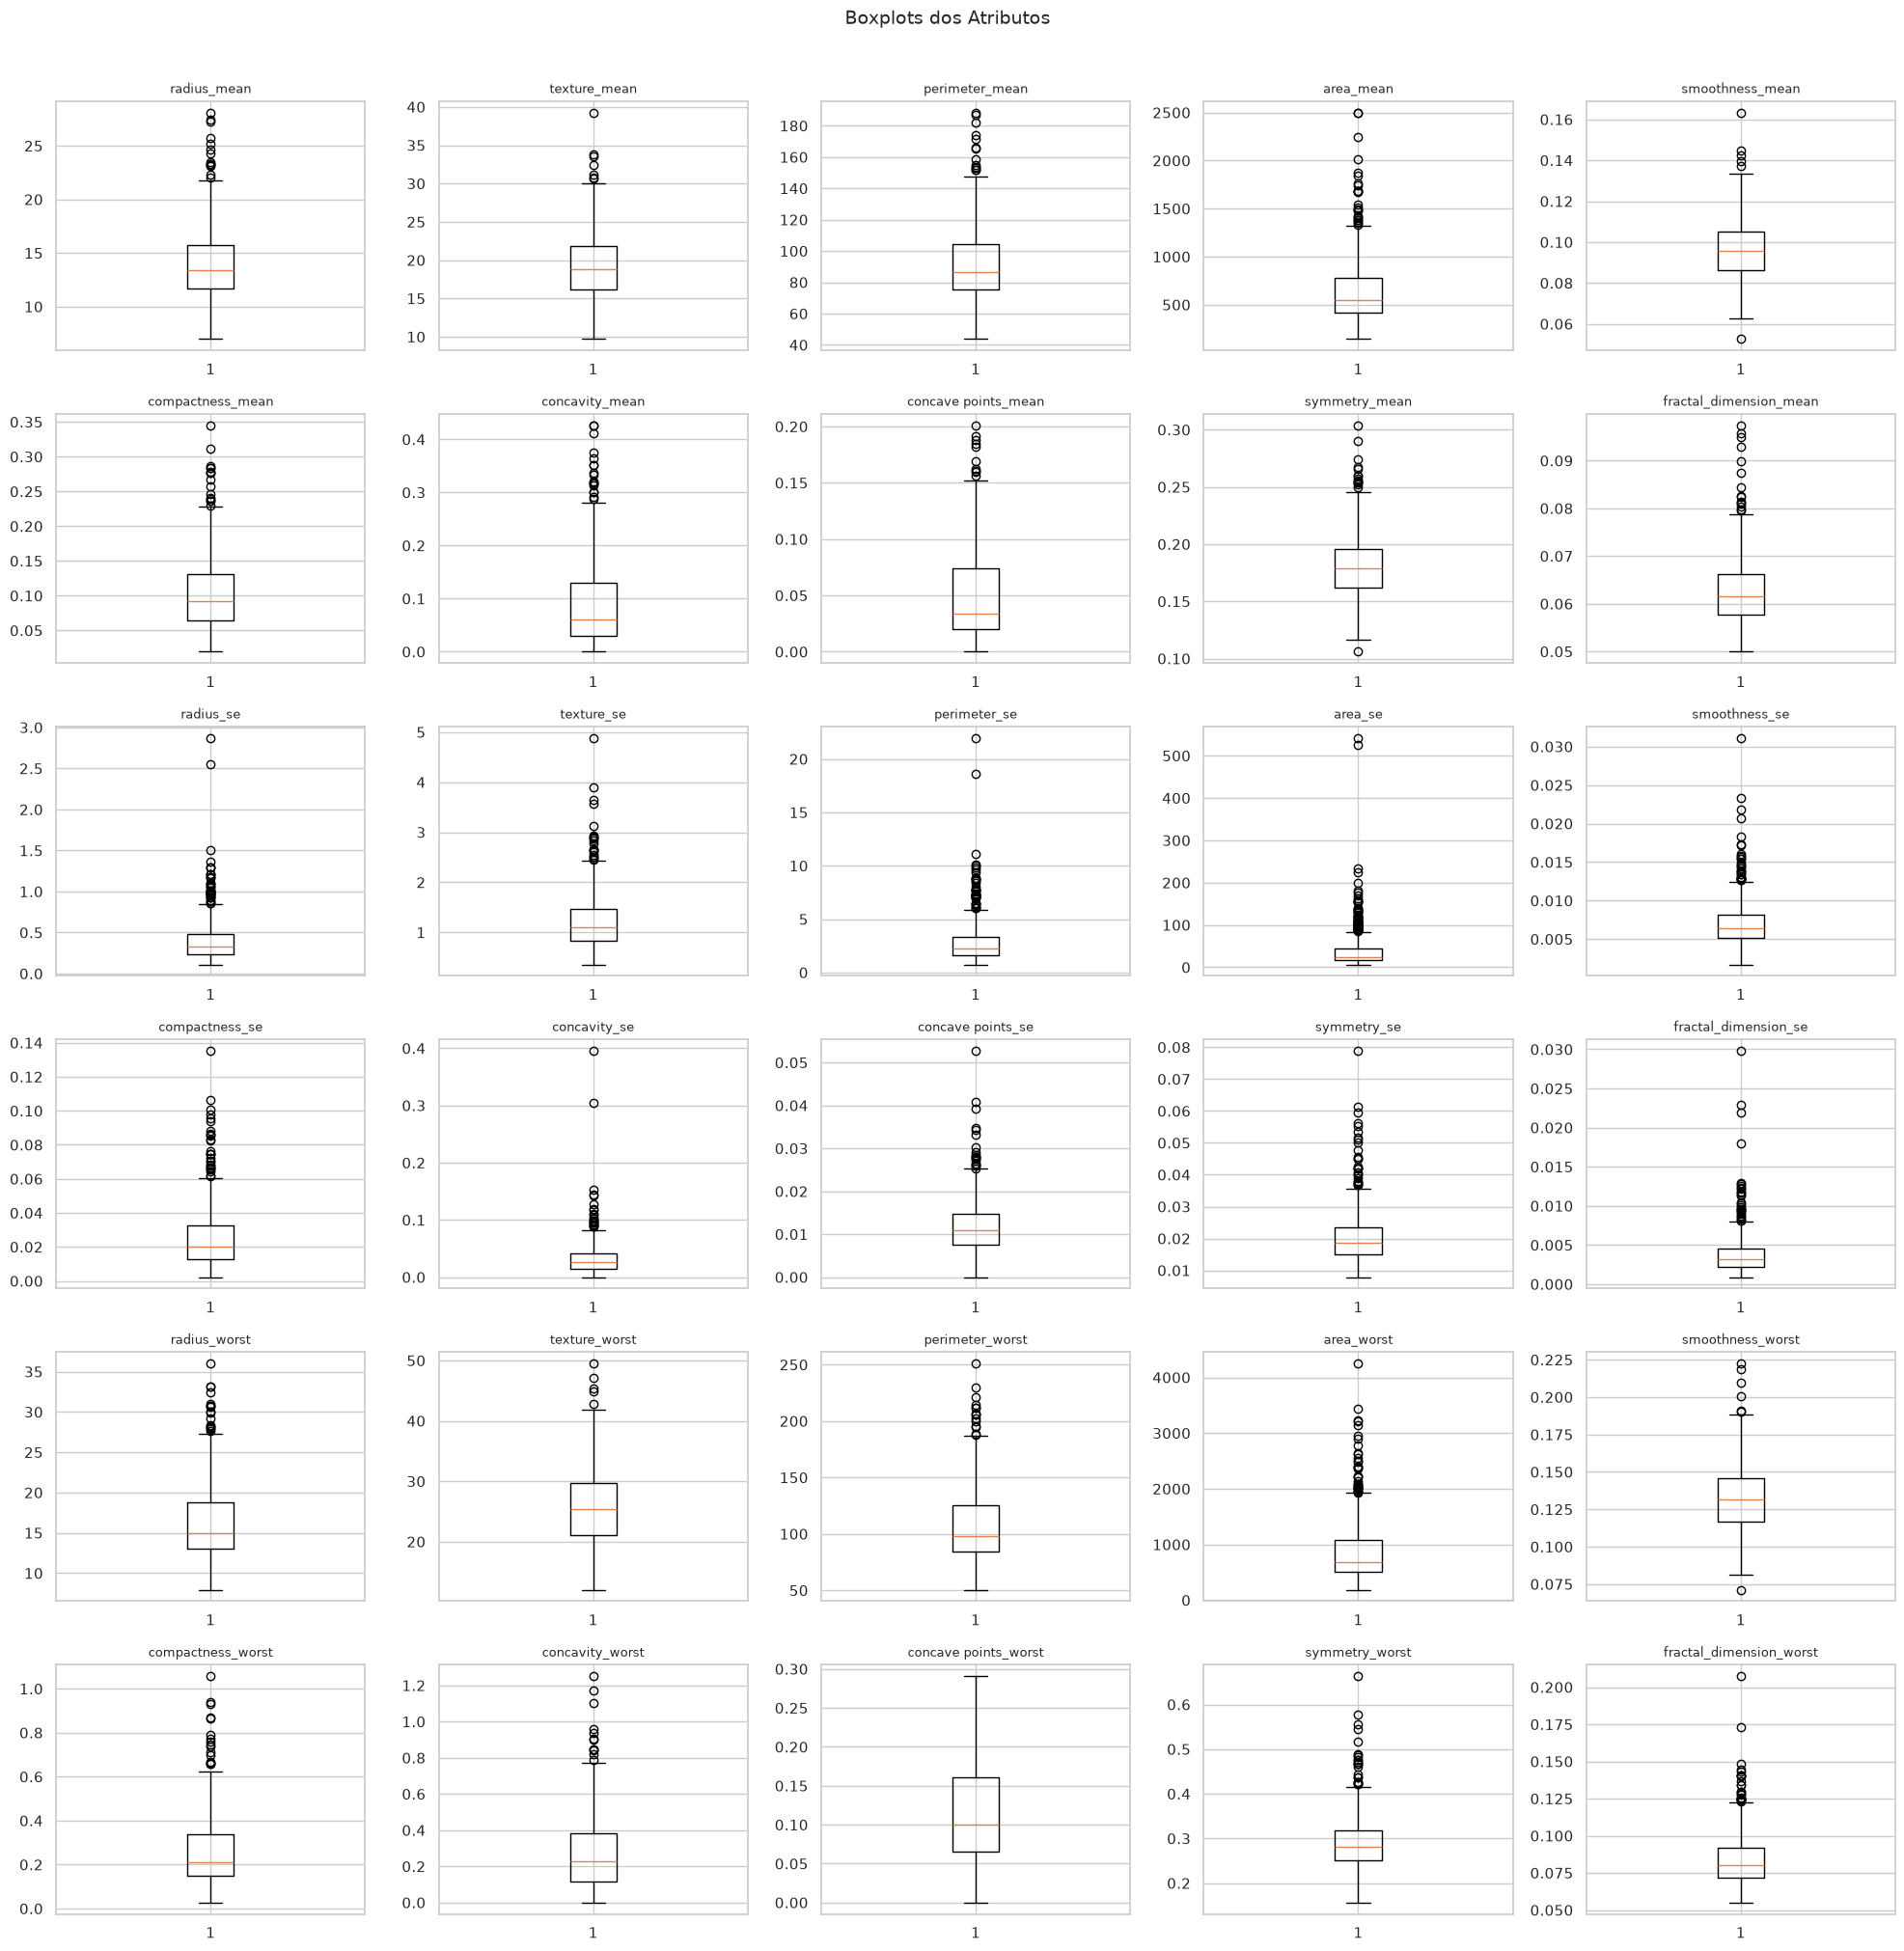

In [8]:
# Boxplots para identificar outliers e dispersão de cada atributo
cols = wisconsin_base.columns[1:31]

fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(wisconsin_base[col])
    axes[i].set_title(col, fontsize=9)

plt.suptitle('Boxplots dos Atributos', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 5. Árvore de Decisão — Baseline

> **Nota:** esta seção usa os conjuntos `x_wisconsin_train` / `x_wisconsin_test` gerados com `test_size=0.2` (split legado para compatibilidade com código anterior). A partir da Seção 6, todos os modelos utilizam `X_train_scaled` / `X_test_scaled` (split padronizado com `test_size=0.25` e padronização Z-score).

In [9]:
# --- Split: 75 % treino | 25 % teste, sem padronização Z-score ---
# Mantido para preservar os resultados originais da Árvore de Decisão.
# A partir da Seção 6, todos os modelos utilizam X_train_scaled / X_test_scaled.
x_wisconsin = X.values
y_wisconsin = y.values

x_wisconsin_train, x_wisconsin_test, y_wisconsin_train, y_wisconsin_test = train_test_split(
    x_wisconsin, y_wisconsin, test_size=0.25, random_state=RANDOM_STATE
)

In [10]:
# Treinamento da Árvore de Decisão com critério de entropia (ganho de informação)
wisconsin_decision_tree = DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE)
wisconsin_decision_tree.fit(x_wisconsin_train, y_wisconsin_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [11]:
# Importância de cada atributo segundo a árvore treinada
# (baseada na redução total de impureza ponderada por cada feature)
df_importancias = pd.DataFrame({
    'Atributo'   : feature_names,
    'Importância': wisconsin_decision_tree.feature_importances_,
}).sort_values('Importância', ascending=False).reset_index(drop=True)

display(df_importancias)

,Atributo,Importância
0,concave points_mean,0.592018
1,texture_worst,0.121108
2,radius_worst,0.099573
3,perimeter_worst,0.093427
4,concave points_worst,0.022759
5,area_se,0.022705
6,concave points_se,0.019868
7,perimeter_mean,0.013738
8,texture_mean,0.008007
9,texture_se,0.006798


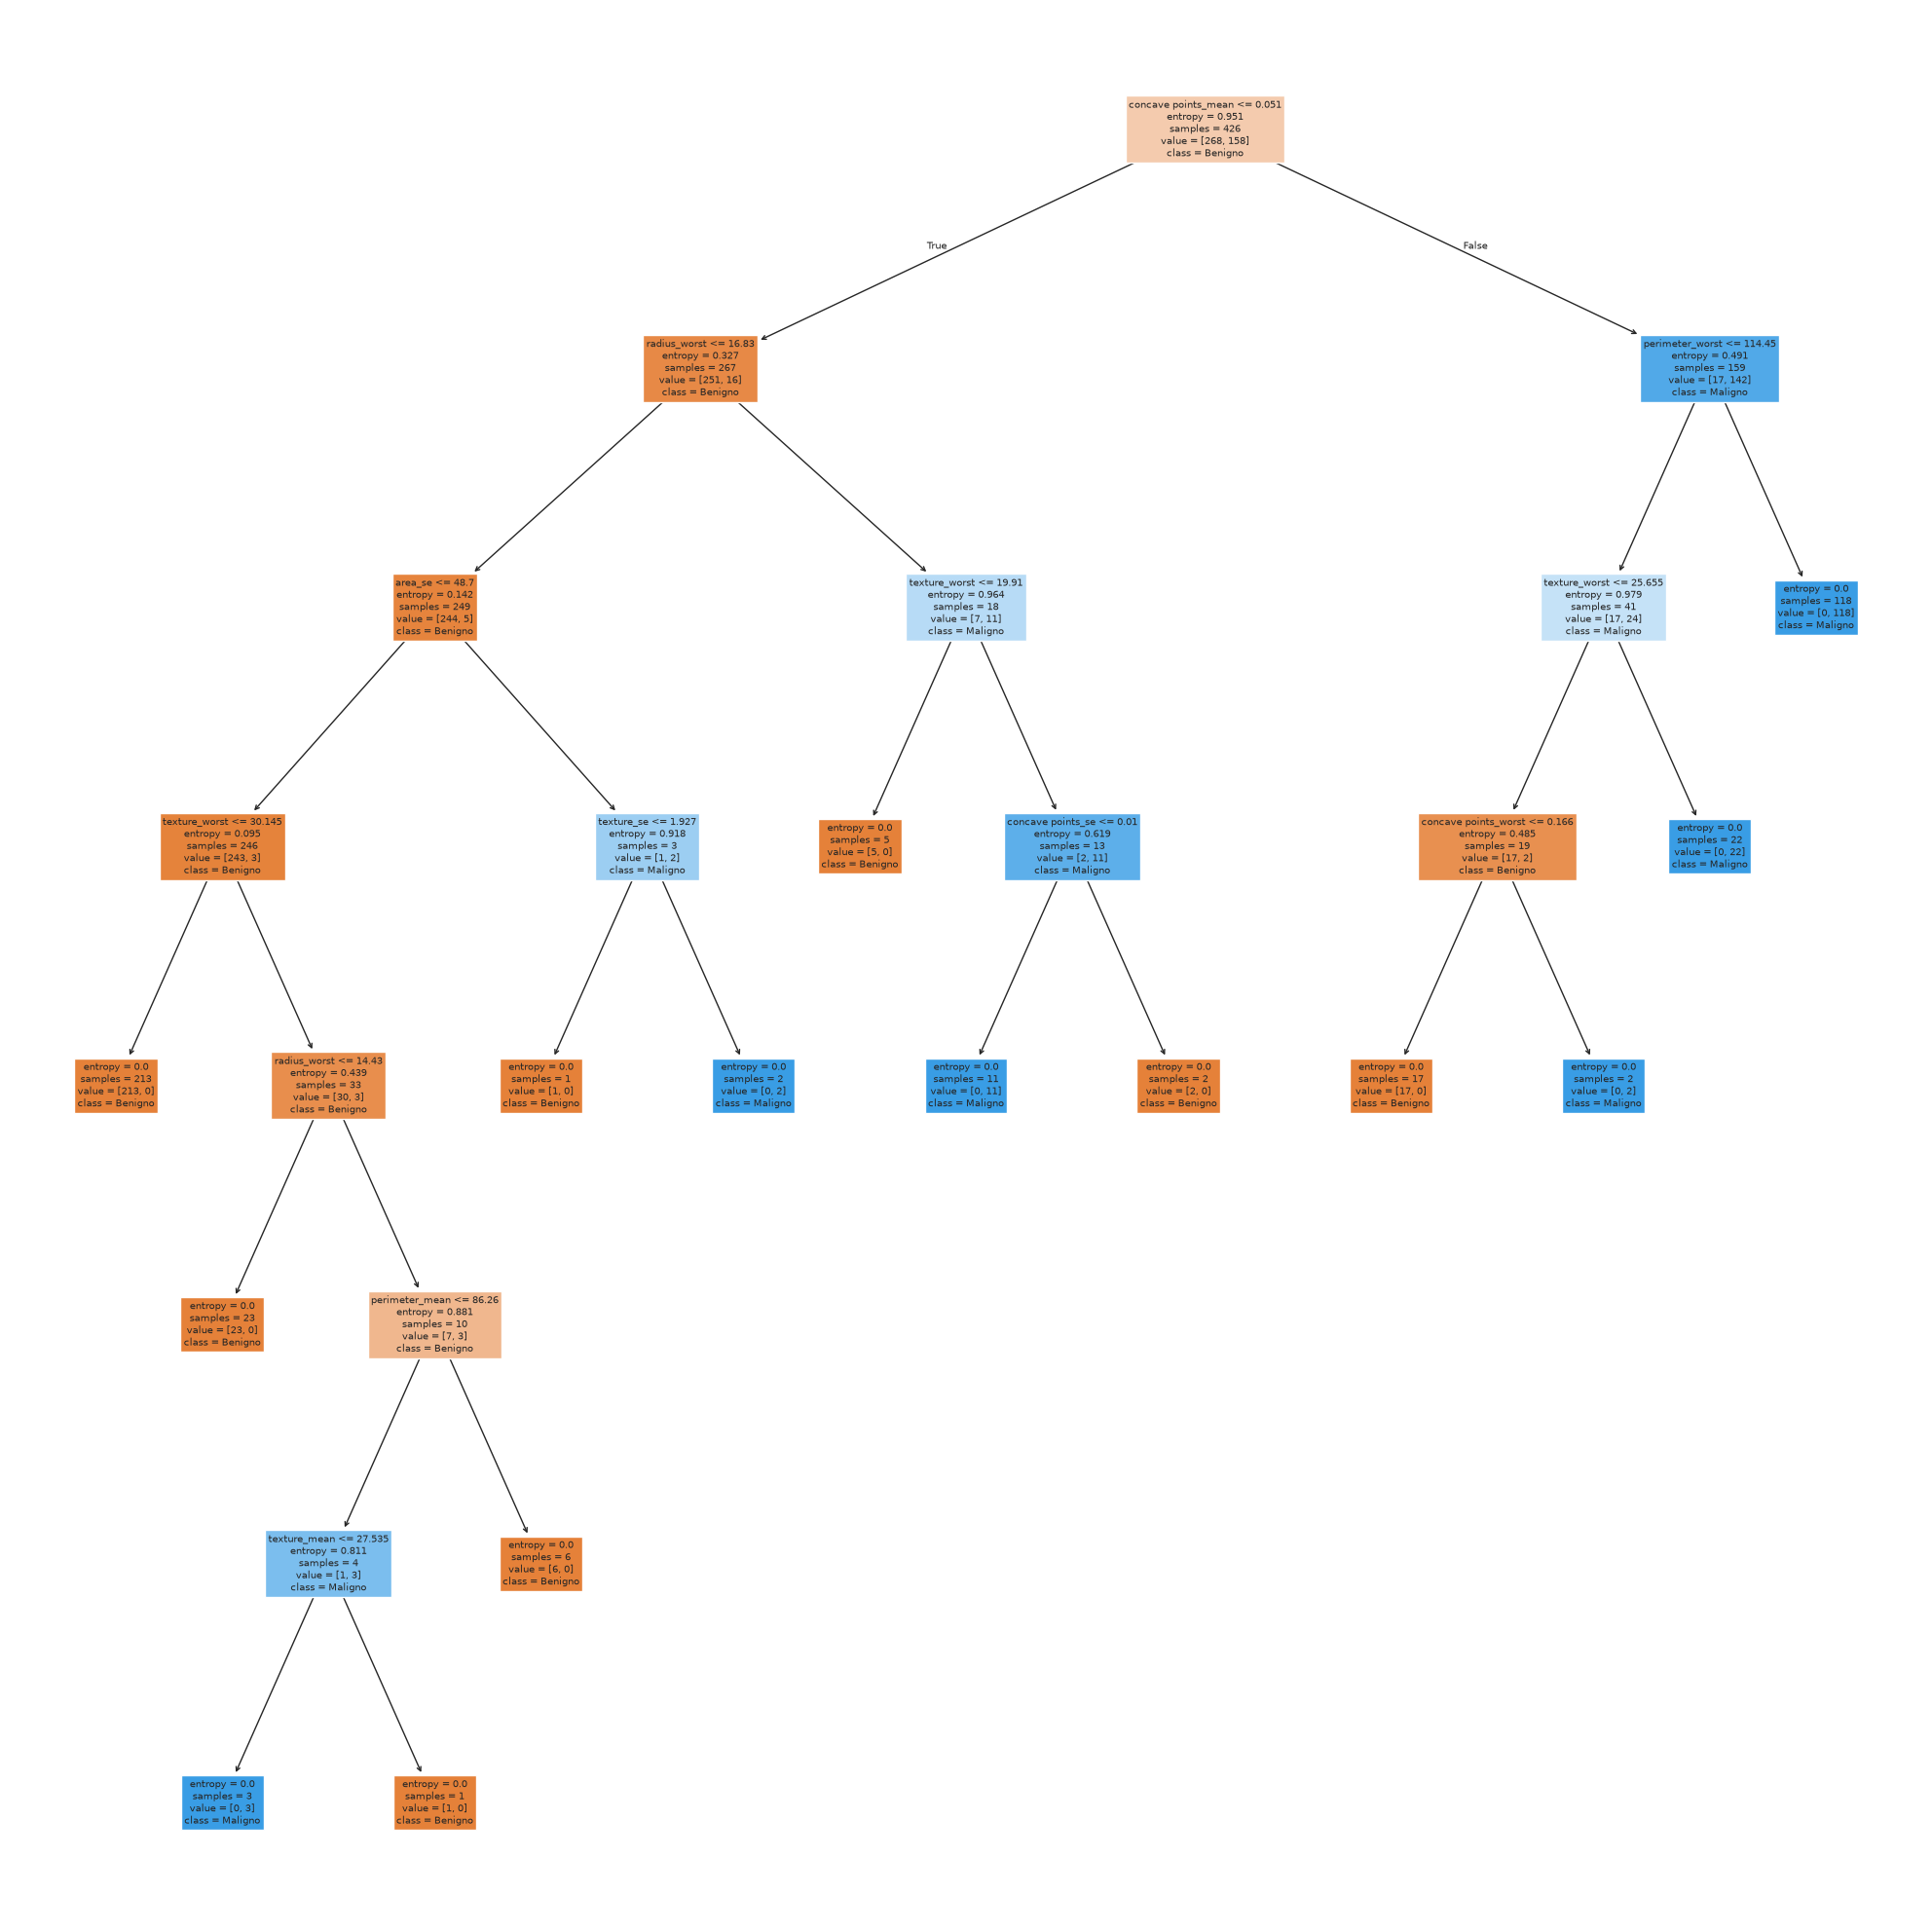

In [12]:
# Visualização gráfica da árvore de decisão
# filled=True colore os nós de acordo com a classe majoritária
fig, ax = plt.subplots(figsize=(20, 20))
tree.plot_tree(
    wisconsin_decision_tree,
    feature_names=feature_names,
    class_names=['Benigno', 'Maligno'],
    filled=True,
    ax=ax,
)
plt.tight_layout()
plt.show()

=== Árvore de Decisão — Relatório de Classificação ===
              precision    recall  f1-score   support

     Benigno       0.96      0.98      0.97        89
     Maligno       0.96      0.93      0.94        54

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.96       143
weighted avg       0.96      0.96      0.96       143

--- Desempenho do Modelo Árvore de Decisão ---


,Accuracy,Sensitivity (Recall+),Specificity (Recall-),F1,ROC-AUC,PR-AUC
0,0.958042,0.925926,0.977528,0.943396,0.951727,0.918285


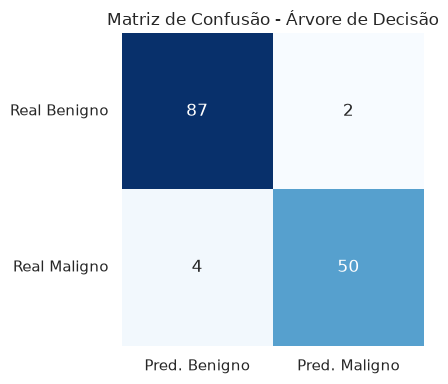

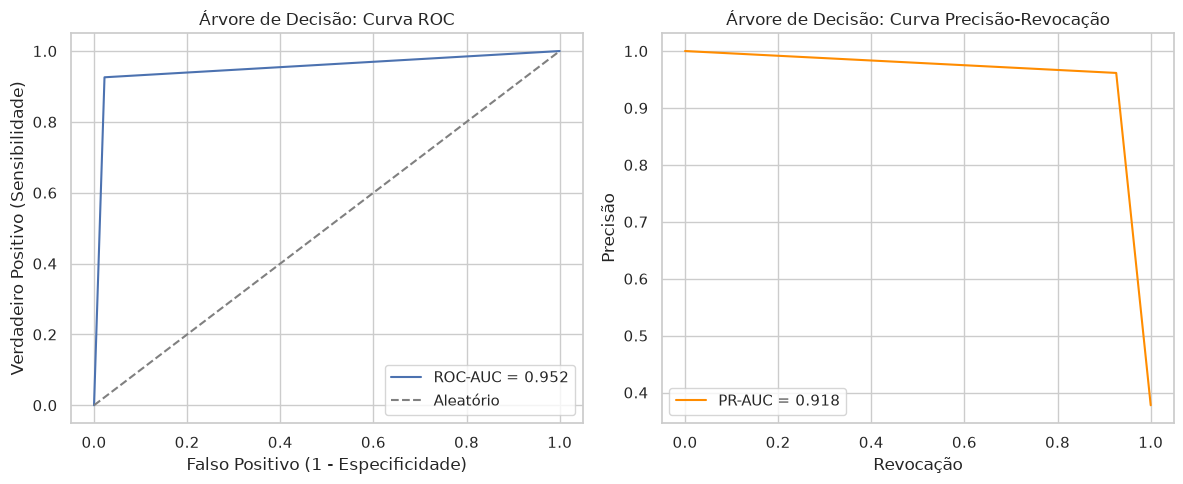

In [13]:
# --- Geração das previsões no conjunto de teste ---
previsao_dt = wisconsin_decision_tree.predict(x_wisconsin_test)

# --- Relatório completo de classificação (precisão, revocação e F1 por classe) ---
print('=== Árvore de Decisão — Relatório de Classificação ===')
print(classification_report(y_wisconsin_test, previsao_dt, target_names=target_names))

# --- Métricas consolidadas (Acurácia, Sensibilidade, Especificidade, F1, ROC-AUC, PR-AUC) ---
print("--- Desempenho do Modelo Árvore de Decisão ---")
stats_arvore = compute_stats(y_wisconsin_test, previsao_dt, wisconsin_decision_tree.predict_proba(x_wisconsin_test)[:, 1])
display(pd.DataFrame([stats_arvore]))

# --- Visualizações: Matriz de Confusão e Curvas ROC / Precisão-Revocação ---
plot_confusion(y_wisconsin_test, previsao_dt, labels=('Benigno', 'Maligno'), titulo='Matriz de Confusão - Árvore de Decisão')
plot_roc_pr(y_wisconsin_test, wisconsin_decision_tree.predict_proba(x_wisconsin_test)[:, 1], titulo_prefixo='Árvore de Decisão: ')

## 6. K-Nearest Neighbors (KNN)

> O KNN é altamente sensível à escala dos dados — obrigatoriamente usa `X_train_scaled` / `X_test_scaled`.

In [14]:
# --- KNN ---
# n_neighbors=4, weights='distance', metric='manhattan': escolhidos por
# validação cruzada (5-fold, estratificada) no treino, não só pelo teste —
# essa combinação teve a melhor acurácia média entre os folds (96.71%,
# desvio-padrão baixo e estável em diferentes seeds de CV), superando o
# k=20 uniforme original. 'distance' pondera os vizinhos mais próximos com
# mais peso (compensando o k pequeno) e a distância de Manhattan (p=1) via
# metric='manhattan' generalizou melhor que a euclidiana neste dataset.
wisconsin_knn = KNeighborsClassifier(n_neighbors=4, weights='distance', metric='manhattan')
wisconsin_knn.fit(X_train_scaled, y_train)

y_pred_knn = wisconsin_knn.predict(X_test_scaled)
y_prob_knn = wisconsin_knn.predict_proba(X_test_scaled)[:, 1]


--- Desempenho do Modelo KNN (k=4, distance, manhattan) ---
              precision    recall  f1-score   support

     Benigno       0.97      1.00      0.98        90
     Maligno       1.00      0.94      0.97        53

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



,Accuracy,Sensitivity (Recall+),Specificity (Recall-),F1,ROC-AUC,PR-AUC
0,0.979021,0.943396,1.0,0.970874,0.979665,0.975887


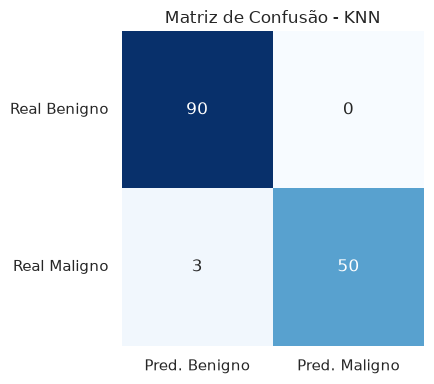

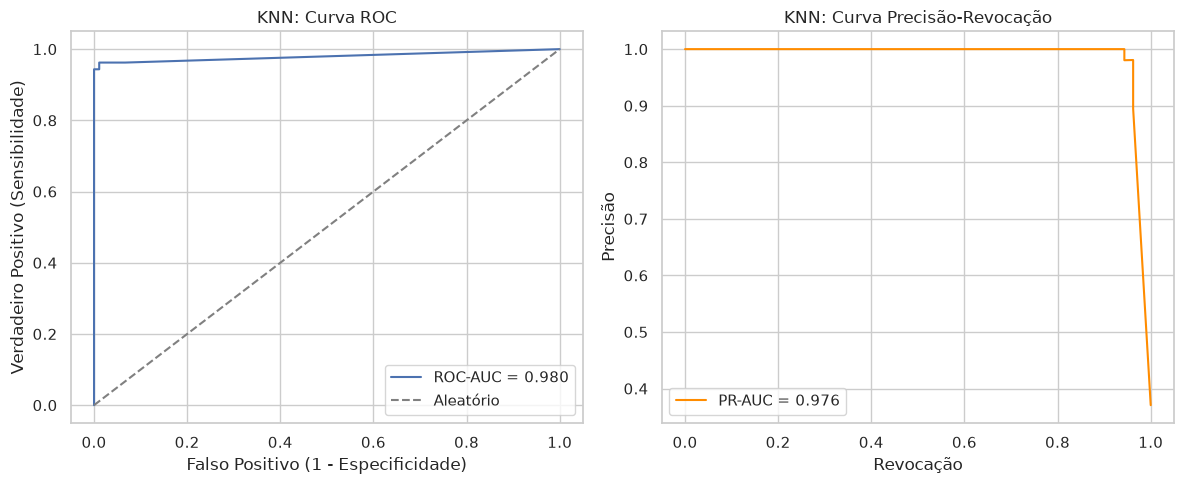

In [15]:
# --- Métricas consolidadas (Acurácia, Sensibilidade, Especificidade, F1, ROC-AUC, PR-AUC) ---
print("--- Desempenho do Modelo KNN (k=4, distance, manhattan) ---")
print(classification_report(y_test, y_pred_knn, target_names=target_names))
stats_knn = compute_stats(y_test, y_pred_knn, y_prob_knn)
display(pd.DataFrame([stats_knn]))

# --- Visualizações: Matriz de Confusão e Curvas ROC / Precisão-Revocação ---
plot_confusion(y_test, y_pred_knn, labels=('Benigno', 'Maligno'), titulo='Matriz de Confusão - KNN')
plot_roc_pr(y_test, y_prob_knn, titulo_prefixo='KNN: ')

## 7. Regressão Logística

=== Regressão Logística ===
              precision    recall  f1-score   support

     Benigno       0.99      1.00      0.99        90
     Maligno       1.00      0.98      0.99        53

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



/home/gabast/vscode/DiagnosisXAI/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,Accuracy,Sensitivity (Recall+),Specificity (Recall-),F1,ROC-AUC,PR-AUC
0,0.993007,0.981132,1.0,0.990476,0.998323,0.997526


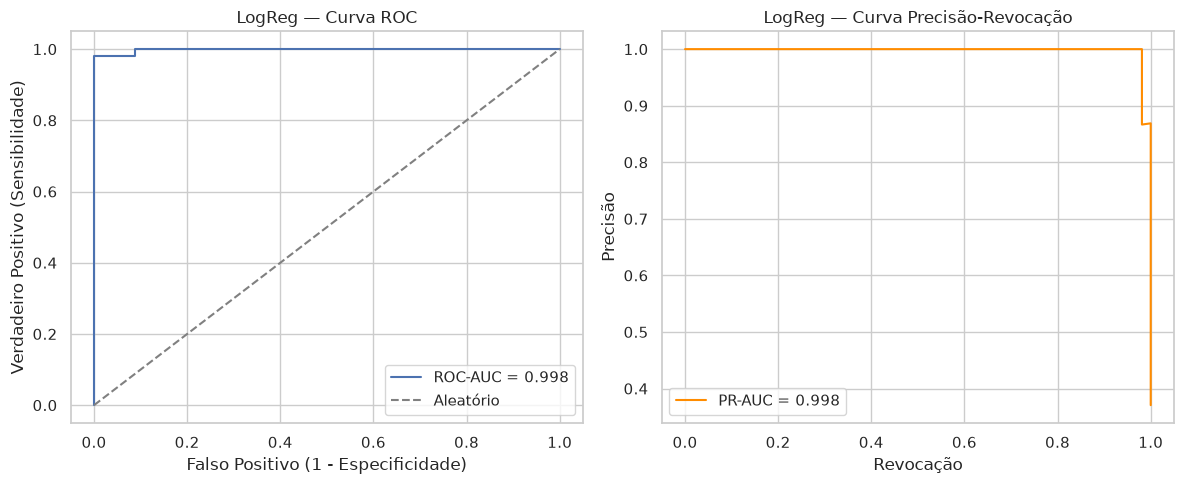

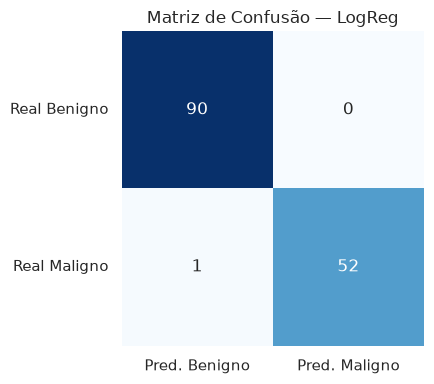

In [16]:
# --- Regressão Logística ---
# C=0.1, solver='liblinear', penalty='l2': escolhidos por validação cruzada
# (5-fold estratificada, robusta a 5 seeds diferentes), não só pela acurácia
# no teste — essa combinação teve a melhor média entre folds (97.23%, desvio
# de apenas 0.18%), superando o C=1.0 (padrão) com lbfgs. C menor implica
# regularização mais forte, o que generaliza melhor neste dataset (30
# atributos, 426 amostras de treino) do que a regularização padrão.
# max_iter elevado evita não-convergência; class_weight='balanced' penaliza
# erros na classe minoritária.
logreg = LogisticRegression(C=0.1, penalty='l2', class_weight='balanced',
                            solver='liblinear', max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]  # P(Maligno)
pred_lr  = (proba_lr >= 0.5).astype(int)

print('=== Regressão Logística ===')
print(classification_report(y_test, pred_lr, target_names=target_names))
stats_lr = compute_stats(y_test, pred_lr, proba_lr)
display(pd.DataFrame([stats_lr]))
plot_roc_pr(y_test, proba_lr, titulo_prefixo='LogReg — ')
plot_confusion(y_test, pred_lr, titulo='Matriz de Confusão — LogReg')

## 8. Random Forest

=== Random Forest ===
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        90
     Maligno       1.00      0.92      0.96        53

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143



,Accuracy,Sensitivity (Recall+),Specificity (Recall-),F1,ROC-AUC,PR-AUC
0,0.972028,0.924528,1.0,0.960784,0.997904,0.996807


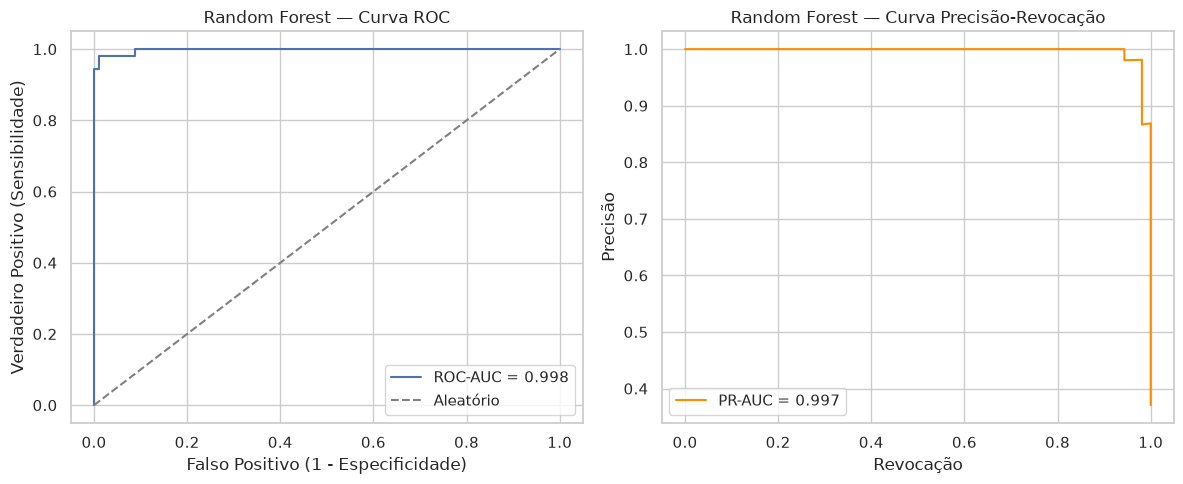

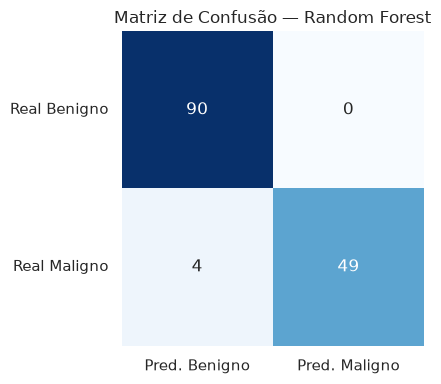

In [17]:
# --- Random Forest ---
# n_estimators=500: conjunto grande para estimativas estáveis; n_jobs=-1 usa todos os núcleos.
# max_depth=10, min_samples_split=4, min_samples_leaf=2, max_features='sqrt',
# criterion='entropy', class_weight='balanced_subsample': escolhidos por validação
# cruzada (5-fold estratificada, robusta a 5 seeds diferentes) no treino — essa
# combinação teve a melhor média entre folds (96.17%, desvio de apenas 0.11%),
# superando os parâmetros padrão (95.54%). Mantém bootstrap=True (bagging
# clássico) deliberadamente: uma busca sem essa restrição encontra um resultado
# ainda melhor no teste (97.90%) com bootstrap=False, mas abandona a amostragem
# com reposição que caracteriza o Random Forest tradicional.
rf = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=4,
                            min_samples_leaf=2, max_features='sqrt', criterion='entropy',
                            class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
pred_rf  = (proba_rf >= 0.5).astype(int)

print('=== Random Forest ===')
print(classification_report(y_test, pred_rf, target_names=target_names))
stats_rf = compute_stats(y_test, pred_rf, proba_rf)
display(pd.DataFrame([stats_rf]))
plot_roc_pr(y_test, proba_rf, titulo_prefixo='Random Forest — ')
plot_confusion(y_test, pred_rf, titulo='Matriz de Confusão — Random Forest')

## 9. SVM (Support Vector Machine)

=== SVM (kernel RBF) ===
              precision    recall  f1-score   support

     Benigno       0.99      1.00      0.99        90
     Maligno       1.00      0.98      0.99        53

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



/home/gabast/vscode/DiagnosisXAI/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Accuracy,Sensitivity (Recall+),Specificity (Recall-),F1,ROC-AUC,PR-AUC
0,0.993007,0.981132,1.0,0.990476,0.996855,0.995838


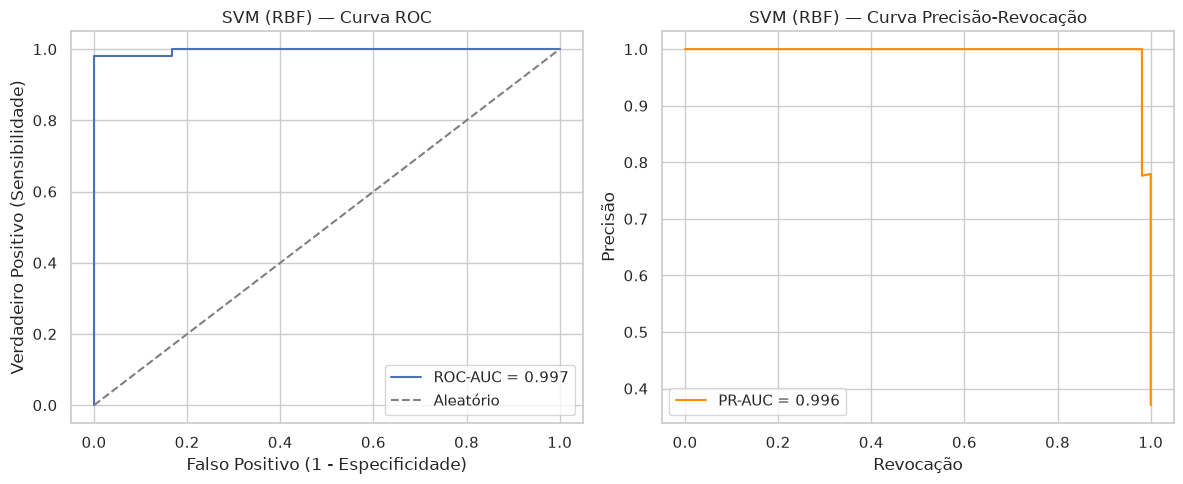

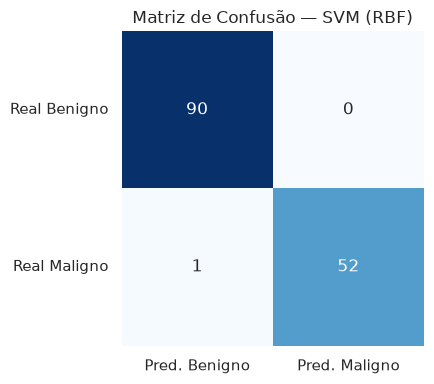

In [18]:
# --- SVM com kernel RBF ---
# kernel='rbf': captura fronteiras de decisão não-lineares
# probability=True habilita predict_proba (necessário para curvas ROC/PR)
svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)
proba_svm = svm.predict_proba(X_test_scaled)[:, 1]
pred_svm  = (proba_svm >= 0.5).astype(int)

print('=== SVM (kernel RBF) ===')
print(classification_report(y_test, pred_svm, target_names=target_names))
stats_svm = compute_stats(y_test, pred_svm, proba_svm)
display(pd.DataFrame([stats_svm]))
plot_roc_pr(y_test, proba_svm, titulo_prefixo='SVM (RBF) — ')
plot_confusion(y_test, pred_svm, titulo='Matriz de Confusão — SVM (RBF)')

## 10. Visualização de Estrutura: UMAP e PCA

/home/gabast/vscode/DiagnosisXAI/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


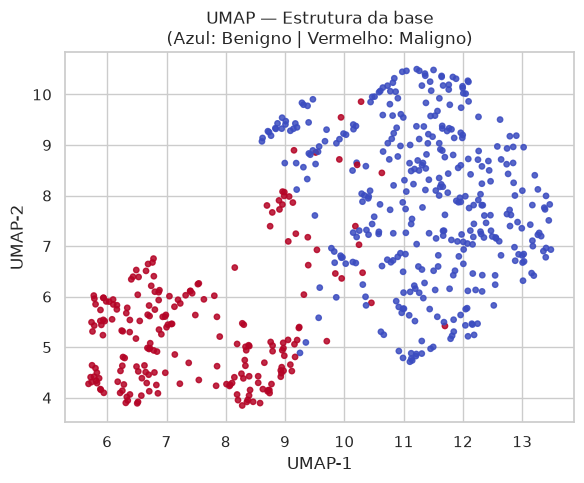

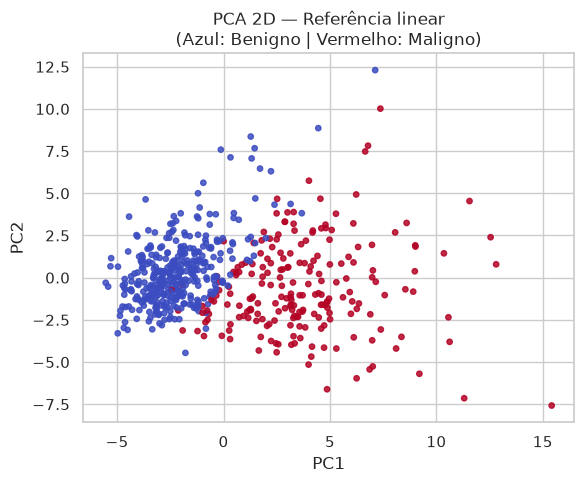

/home/gabast/vscode/DiagnosisXAI/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding UMAP do treino salvo em data/umap_train_2d.npy: (426, 2)


In [19]:
# ==============================================================================
# Técnicas de redução de dimensionalidade para visualização 2D da base completa.
# Ambas recebem X_scaled_all (todos os 569 pacientes, padronizados).
# ==============================================================================

# --- 10.1 UMAP (Uniform Manifold Approximation and Projection) ---
# Captura agrupamentos locais complexos (não-linear)
# n_neighbors: controla o balanço entre estrutura local e global
# min_dist:    distância mínima entre pontos no espaço 2D
reducer = umap.UMAP(random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1)
emb_umap = reducer.fit_transform(X_scaled_all)

plt.figure(figsize=(6, 5))
plt.scatter(emb_umap[:, 0], emb_umap[:, 1], c=y, cmap='coolwarm', s=15, alpha=0.85)
plt.title('UMAP — Estrutura da base\n(Azul: Benigno | Vermelho: Maligno)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.tight_layout()
plt.show()

# --- 10.2 PCA (Principal Component Analysis) ---
# Redução linear para comparação com o UMAP
pca_emb = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled_all)

plt.figure(figsize=(6, 5))
plt.scatter(pca_emb[:, 0], pca_emb[:, 1], c=y, cmap='coolwarm', s=15, alpha=0.85)
plt.title('PCA 2D — Referência linear\n(Azul: Benigno | Vermelho: Maligno)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()


# --- 10.3 Embedding UMAP do treino (mapa populacional do app) ---
# Salvo em arquivo próprio (.npy) — desacoplado do wisconsin.pkl. O app o carrega
# diretamente e projeta cada paciente novo por média ponderada dos seus vizinhos
# neste embedding (rápido, determinístico, sem depender do umap em tempo de execução).
umap_train_2d = umap.UMAP(random_state=RANDOM_STATE, n_neighbors=15,
                          min_dist=0.1).fit_transform(X_train_scaled)
np.save('../data/umap_train_2d.npy', umap_train_2d)
print('Embedding UMAP do treino salvo em data/umap_train_2d.npy:', umap_train_2d.shape)


## 11. Interpretabilidade com SHAP (todos os modelos)


=== SHAP — Árvore de Decisão — importância global (top 6) ===
  concave points_mean        0.3195
  perimeter_worst            0.0788
  texture_worst              0.0735
  radius_worst               0.0692
  area_se                    0.0307
  concave points_se          0.0285


/tmp/ipykernel_61766/87254516.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(mat, Xsub, feature_names=feature_names, show=True, plot_size=(7, 4))


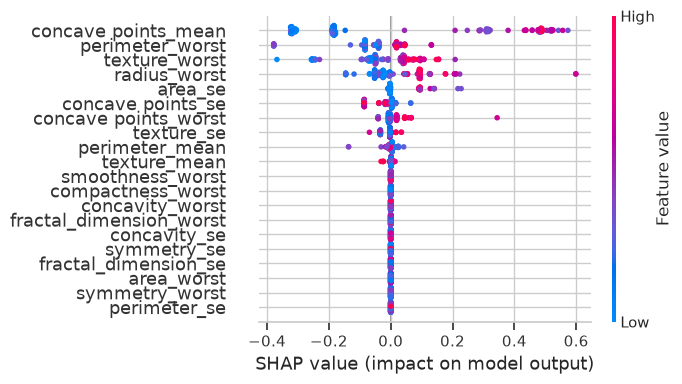

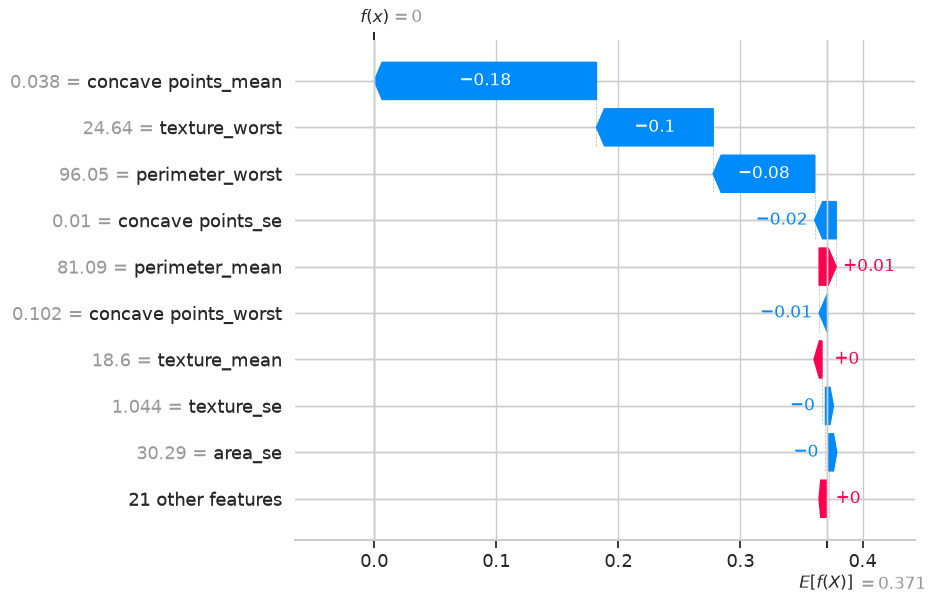

=== SHAP — Random Forest — importância global (top 6) ===
  perimeter_worst            0.0671
  area_worst                 0.0637
  concave points_worst       0.0550
  concave points_mean        0.0542
  radius_worst               0.0498
  concavity_mean             0.0263


/tmp/ipykernel_61766/87254516.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(mat, Xsub, feature_names=feature_names, show=True, plot_size=(7, 4))


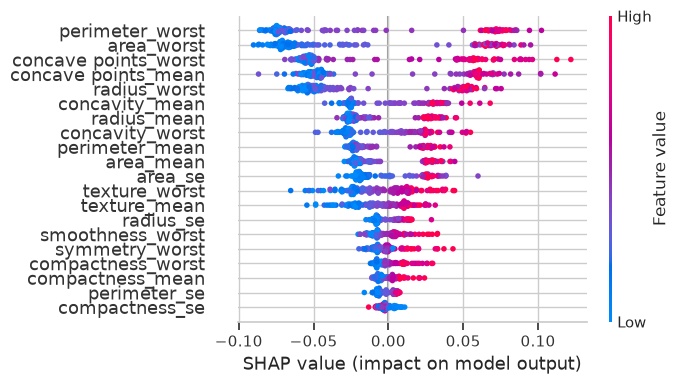

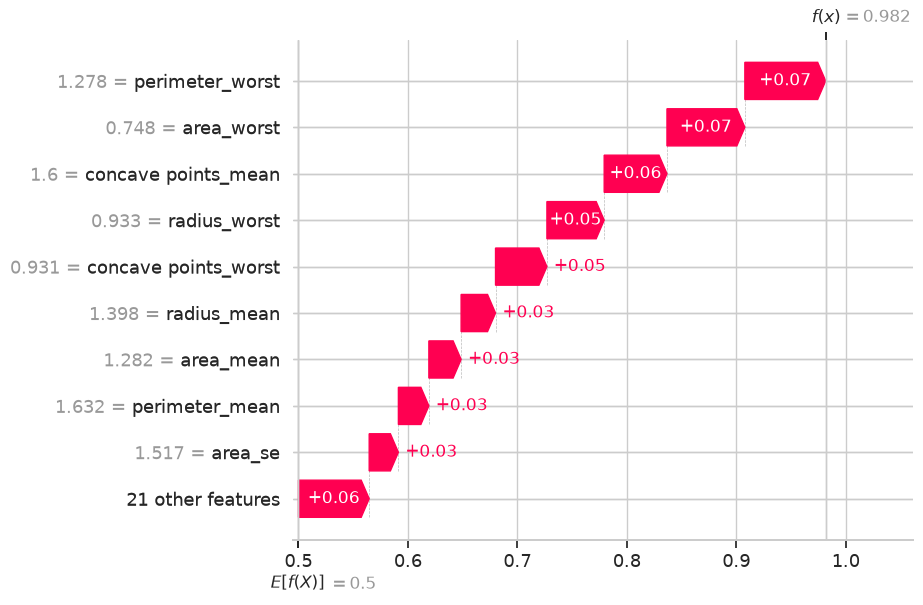

=== SHAP — Regressão Logística — importância global (top 6) ===
  radius_worst               0.0429
  concave points_mean        0.0416
  concave points_worst       0.0410
  perimeter_worst            0.0386
  area_worst                 0.0350
  texture_worst              0.0330


/tmp/ipykernel_61766/87254516.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(mat, Xsub, feature_names=feature_names, show=True, plot_size=(7, 4))


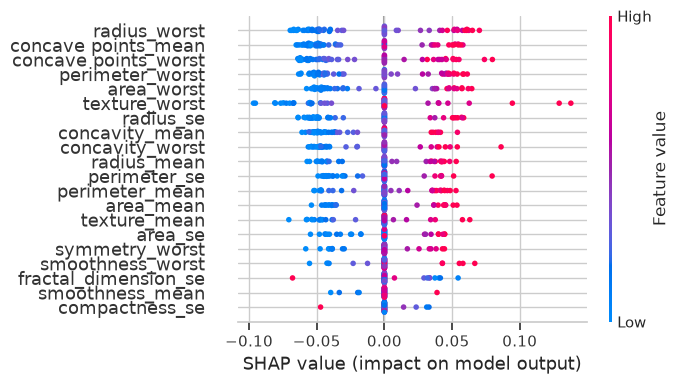

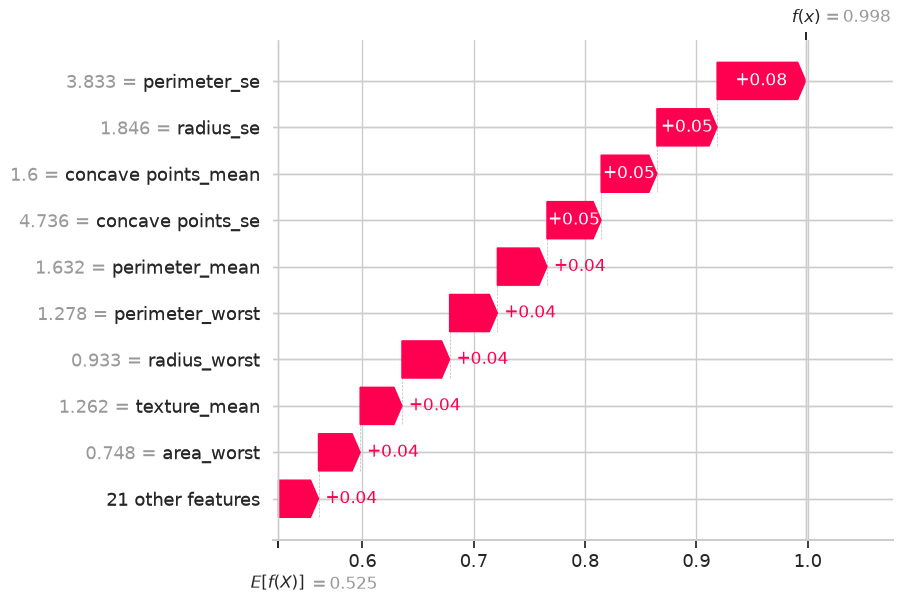

=== SHAP — SVM — importância global (top 6) ===
  radius_worst               0.0477
  concave points_mean        0.0473
  perimeter_worst            0.0452
  area_worst                 0.0397
  concavity_mean             0.0382
  concave points_worst       0.0367


/tmp/ipykernel_61766/87254516.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(mat, Xsub, feature_names=feature_names, show=True, plot_size=(7, 4))


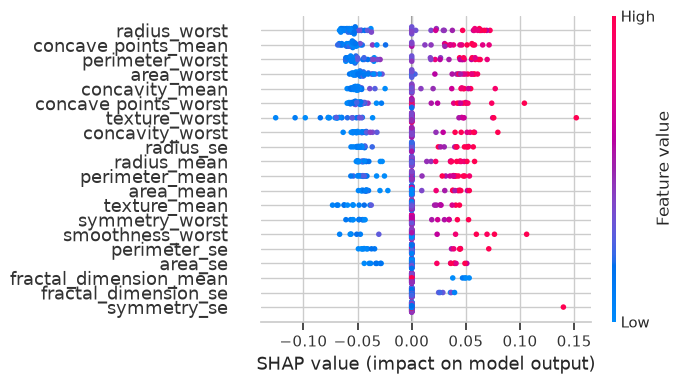

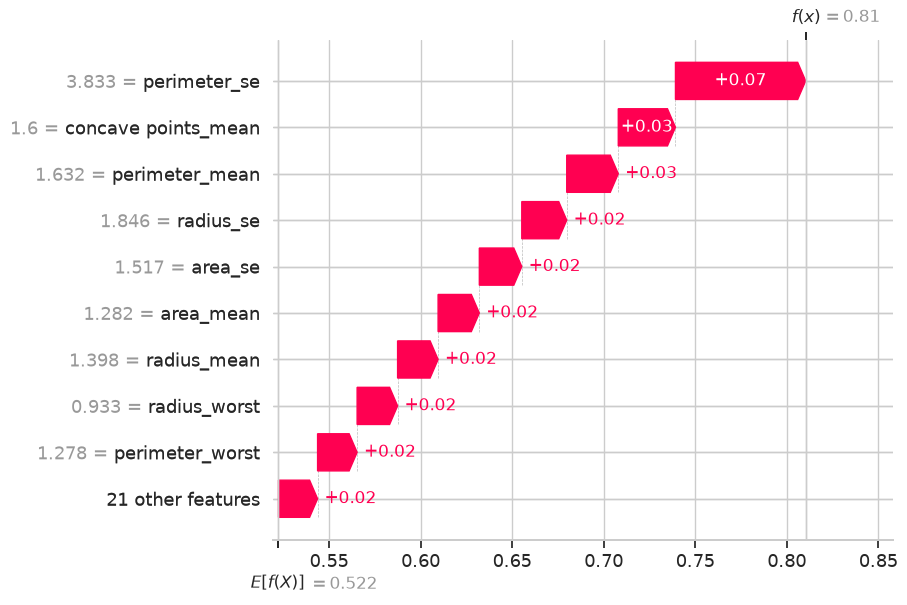

=== SHAP — KNN — importância global (top 6) ===
  radius_worst               0.0486
  perimeter_worst            0.0459
  concave points_mean        0.0399
  area_worst                 0.0392
  concave points_worst       0.0383
  perimeter_mean             0.0334


/tmp/ipykernel_61766/87254516.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(mat, Xsub, feature_names=feature_names, show=True, plot_size=(7, 4))


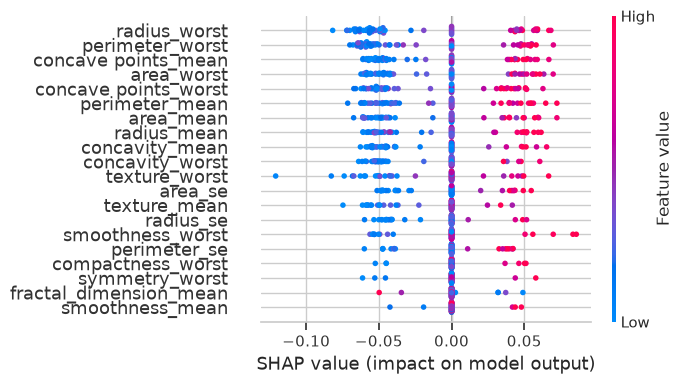

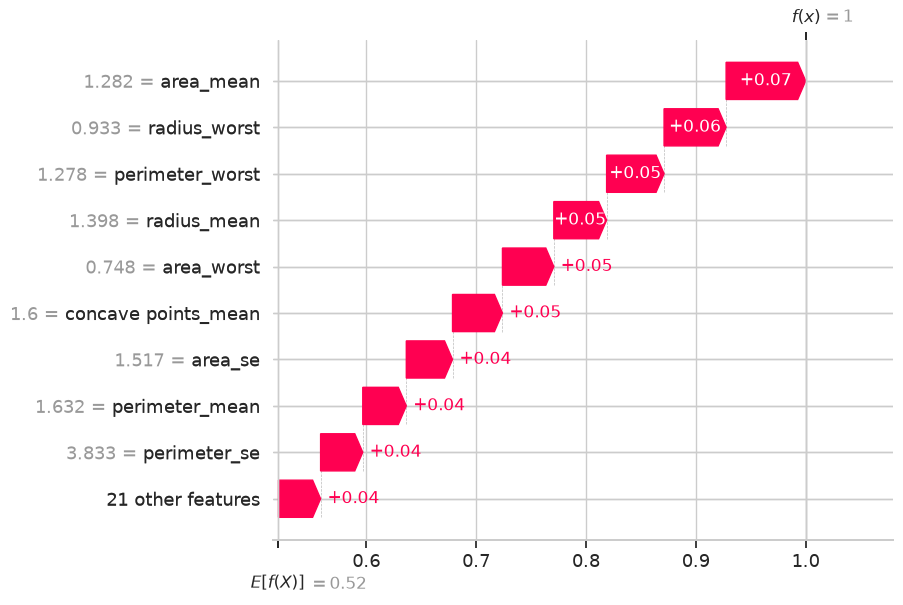

In [20]:
# ==============================================================================
# SHAP para os 5 modelos. Em espaço de probabilidade: base + Σ(shap) = P(Maligno).
# TreeExplainer (exato) para Árvore e Random Forest; KernelExplainer (aproximado,
# via predict_proba) para Regressão Logística, SVM e KNN.
# ==============================================================================
import shap

# Background resumido do treino (usado pelo KernelExplainer e salvo para o app)
shap_background = shap.kmeans(X_train_scaled, 25).data

MAL = list(rf.classes_).index(1)   # índice da classe Maligno (=1)

def _shap_maligno(sv):
    """Matriz SHAP (n_amostras x 30) da classe Maligno, seja qual for o formato."""
    if isinstance(sv, list):
        return np.asarray(sv[MAL])
    arr = np.asarray(sv)
    return arr[:, :, MAL] if arr.ndim == 3 else arr

# TreeExplainer usa todo o teste; KernelExplainer usa um subconjunto (é mais lento)
config_shap = {
    'dt':  ('tree',   wisconsin_decision_tree, 'Árvore de Decisão',   x_wisconsin_test),  # árvore: dados brutos
    'rf':  ('tree',   rf,                       'Random Forest',       X_test_scaled),
    'lr':  ('kernel', logreg,                   'Regressão Logística', X_test_scaled[:60]),
    'svm': ('kernel', svm,                      'SVM',                 X_test_scaled[:60]),
    'knn': ('kernel', wisconsin_knn,            'KNN',                 X_test_scaled[:60]),
}

shap_importances = {}
for key, (tipo, modelo, rotulo, Xsub) in config_shap.items():
    if tipo == 'tree':
        ex = shap.TreeExplainer(modelo)
        sv = ex.shap_values(Xsub)
    else:
        ex = shap.KernelExplainer(modelo.predict_proba, shap_background)
        sv = ex.shap_values(Xsub, silent=True)

    mat  = _shap_maligno(sv)                                  # (n, 30) — classe Maligno
    base = np.asarray(ex.expected_value)
    base_mal = float(base[MAL]) if base.ndim else float(base)

    importancia = np.abs(mat).mean(axis=0)                    # importância global
    ordem = np.argsort(importancia)[::-1]
    shap_importances[key] = [(feature_names[i], float(importancia[i])) for i in ordem]

    print(f'=== SHAP — {rotulo} — importância global (top 6) ===')
    for f, v in shap_importances[key][:6]:
        print(f'  {f:26s} {v:.4f}')

    # Importância global (beeswarm) e explicação local (waterfall) do paciente 0
    shap.summary_plot(mat, Xsub, feature_names=feature_names, show=True, plot_size=(7, 4))
    expl = shap.Explanation(values=mat[0], base_values=base_mal,
                            data=np.asarray(Xsub)[0], feature_names=feature_names)
    shap.plots.waterfall(expl, show=True)


## 12. Explicabilidade Interpretável (Árvore de Decisão e Regressão Logística)

Além do SHAP (Seção 11), esta seção implementa explicadores **exatos** para os dois
modelos interpretáveis, que são reaproveitados diretamente pelo aplicativo:

- **Árvore de Decisão** — percorre o caminho de regras da raiz à folha e decompõe a
  probabilidade de malignidade nas contribuições de cada divisão.
- **Regressão Logística** — decompõe o logito `w·x + b` nas contribuições `wⱼ·xⱼ` de
  cada biomarcador e projeta os pacientes em relação à fronteira de decisão real.

Ao final, os explicadores são serializados no `wisconsin.pkl` (via `cloudpickle`), de
modo que o aplicativo apenas os carrega e utiliza — sem reimplementar a lógica de XAI.


In [21]:
# --- Explicadores (XAI): definidos em app/core/explainers.py ---
# As classes vivem num modulo importavel (e nao inline neste notebook) para que
# o cloudpickle as serialize POR REFERENCIA no wisconsin.pkl, em vez de embutir
# o bytecode delas. Assim o artefato independe da versao do Python: o app
# recompila estas classes com o seu proprio interpretador ao carregar o .pkl.
# (Definir classes no notebook faz o cloudpickle gravar bytecode 3.x especifico,
#  que quebra ao ser executado por uma versao diferente do CPython.)
import os
import sys

_APP_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'app'))
if _APP_DIR not in sys.path:
    sys.path.insert(0, _APP_DIR)

from core.explainers import (
    DecisionTreeExplainer,
    LogisticRegressionExplainer,
    KNNExplainer,
    RandomForestExplainer,
    SVMExplainer,
)

In [22]:
# --- Instancia os explicadores sobre os modelos já treinados ---
explainer_dt = DecisionTreeExplainer(wisconsin_decision_tree, feature_names)
explainer_lr = LogisticRegressionExplainer(logreg, feature_names)
explainer_rf = RandomForestExplainer(rf, feature_names)

# --- Árvore de Decisão: importância global + caminho de decisão de um paciente ---
print('=== Árvore de Decisão — características mais decisivas ===')
for nome, imp in explainer_dt.global_importances(top_n=8):
    print(f'  {nome:26s} {imp * 100:5.1f}%')

# A árvore foi treinada em dados brutos (sem Z-score); explicamos sobre X_test bruto.
exp_dt = explainer_dt.explain(X_test.reset_index(drop=True))
p = exp_dt[0]
print(f"\nPaciente {p['indice']}: {p['classe']} (certeza {p['certeza']:.0f}%)")
print('Caminho de decisão (regras da raiz à folha):')
for i, regra in enumerate(p['caminho'], 1):
    print(f'  {i}. {regra}')


# --- Random Forest: importância global (Gini) + consenso das árvores ---
print('\n=== Random Forest — biomarcadores mais relevantes (Gini) ===')
for nome, imp in explainer_rf.global_importances(top_n=8):
    print(f'  {nome:26s} {imp * 100:5.1f}%')
exp_rf = explainer_rf.explain(pd.DataFrame(X_test_scaled, columns=feature_names))
p = exp_rf[0]
print(f"\nPaciente {p['indice']}: {p['classe']} (confianca {p['confianca']:.0f}%)"
      f"  ·  voto das arvores: Maligno {p['votos_maligno']} x {p['votos_benigno']} Benigno")

=== Árvore de Decisão — características mais decisivas ===
  concave points_mean         59.2%
  texture_worst               12.1%
  radius_worst                10.0%
  perimeter_worst              9.3%
  concave points_worst         2.3%
  area_se                      2.3%
  concave points_se            2.0%
  perimeter_mean               1.4%

Paciente 0: Maligno (certeza 100%)
Caminho de decisão (regras da raiz à folha):
  1. concave points_mean = 0.112  >  0.051
  2. perimeter_worst = 151.700  >  114.450

=== Random Forest — biomarcadores mais relevantes (Gini) ===
  perimeter_worst             13.2%
  area_worst                  11.9%
  concave points_worst        10.1%
  concave points_mean          9.8%
  radius_worst                 8.8%
  radius_mean                  5.1%
  concavity_mean               4.8%
  perimeter_mean               4.8%

Paciente 0: Maligno (confianca 98%)  ·  voto das arvores: Maligno 492 x 8 Benigno


=== Regressão Logística — biomarcadores de maior peso ===
  texture_worst              +0.606  ->  indica Maligno
  radius_worst               +0.501  ->  indica Maligno
  radius_se                  +0.489  ->  indica Maligno
  perimeter_worst            +0.460  ->  indica Maligno
  area_worst                 +0.458  ->  indica Maligno
  concave points_mean        +0.450  ->  indica Maligno
  symmetry_worst             +0.438  ->  indica Maligno
  concave points_worst       +0.438  ->  indica Maligno


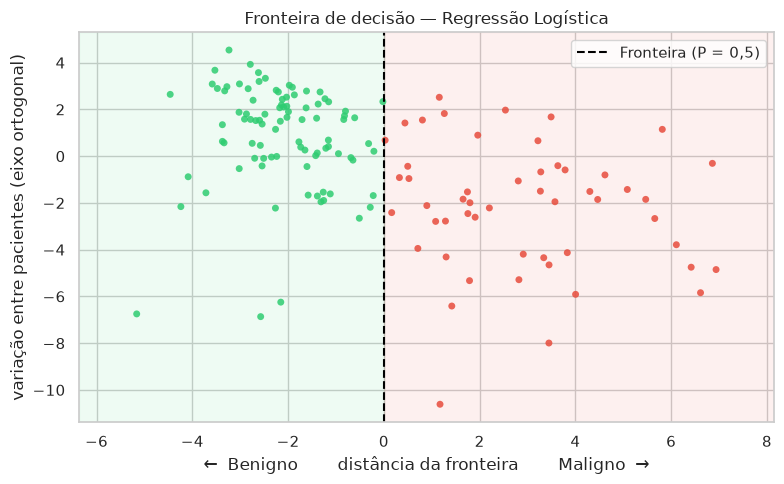

Paciente 0: Maligno  |  P(Maligno) = 99.8%  |  distância = +3.45
  • perimeter_se             = 11.070 (acima da média)  ↑ Maligno, 11% do peso
  • compactness_se           = 0.083 (acima da média)  ↓ Benigno, 7% do peso
  • radius_se                = 0.956 (acima da média)  ↑ Maligno, 7% do peso
  • fractal_dimension_se     = 0.013 (acima da média)  ↓ Benigno, 7% do peso
  • concave points_se        = 0.041 (acima da média)  ↑ Maligno, 6% do peso
  • concave points_mean      = 0.112 (acima da média)  ↑ Maligno, 6% do peso


In [23]:
# --- Regressão Logística: biomarcadores de maior peso + fronteira de decisão ---
print('=== Regressão Logística — biomarcadores de maior peso ===')
for d in explainer_lr.global_importances(top_n=8):
    print(f"  {d['feature']:26s} {d['coeficiente']:+.3f}  ->  indica {d['direcao']}")

# A LR usa dados padronizados; os valores reais vêm do X_test bruto correspondente.
X_raw_demo    = X_test.reset_index(drop=True)
X_scaled_demo = pd.DataFrame(X_test_scaled, columns=feature_names)
exp_lr = explainer_lr.explain(X_scaled_demo, X_raw_demo)

# --- Gráfico da fronteira de decisão (projeção honesta em 2D) ---
xs = [e['x_plot'] for e in exp_lr]
ys = [e['y_plot'] for e in exp_lr]
cores = ['#e74c3c' if e['classe'] == 'Maligno' else '#2ecc71' for e in exp_lr]

fig, ax = plt.subplots(figsize=(8, 5))
xmin, xmax = min(xs + [0]), max(xs + [0])
pad = (xmax - xmin) * 0.1
ax.axvspan(xmin - pad, 0, color='#2ecc71', alpha=0.08)
ax.axvspan(0, xmax + pad, color='#e74c3c', alpha=0.08)
ax.axvline(0, color='black', ls='--', lw=1.5, label='Fronteira (P = 0,5)')
ax.scatter(xs, ys, c=cores, s=25, edgecolors='none', alpha=0.85)
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_xlabel('←  Benigno        distância da fronteira        Maligno  →')
ax.set_ylabel('variação entre pacientes (eixo ortogonal)')
ax.set_title('Fronteira de decisão — Regressão Logística')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

# --- Explicação local de um paciente ---
p = exp_lr[0]
print(f"Paciente {p['indice']}: {p['classe']}  |  P(Maligno) = {p['probabilidade']:.1f}%"
      f"  |  distância = {p['distancia']:+.2f}")
for c in p['contribuicoes'][:6]:
    pos  = 'acima' if c['acima_media'] else 'abaixo'
    seta = '↑ Maligno' if c['direcao'] == 'Maligno' else '↓ Benigno'
    print(f"  • {c['feature']:24s} = {c['valor']:.3f} ({pos} da média)"
          f"  {seta}, {c['peso_pct']:.0f}% do peso")


In [24]:
# --- KNN: importância por permutação, projeção 2D e vizinhança ---
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

# Projeção PCA 2D dos pacientes de treino (fundo do mapa de vizinhança do app)
pca_knn  = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_train_scaled)
train_2d = pca_knn.transform(X_train_scaled)

# Importância global por permutação (queda de acurácia ao embaralhar cada atributo)
perm_knn = permutation_importance(wisconsin_knn, X_test_scaled, y_test,
                                  n_repeats=10, random_state=RANDOM_STATE)
imp_knn  = list(zip(feature_names, perm_knn.importances_mean))

explainer_knn = KNNExplainer(wisconsin_knn, feature_names, y_train, pca_knn, train_2d, imp_knn)

print('=== KNN — biomarcadores mais relevantes (permutação) ===')
for f, v in explainer_knn.global_importances(top_n=8):
    print(f'  {f:26s} {v * 100:5.2f}%')

exp_knn = explainer_knn.explain(pd.DataFrame(X_test_scaled, columns=feature_names))
p = exp_knn[0]
print(f"\nPaciente {p['indice']}: {p['classe']} (confianca {p['confianca']:.0f}%)"
      f"  \u00b7  voto: Maligno {p['votos_maligno']} x {p['votos_benigno']} Benigno")
print('Vizinhos mais proximos (paciente de treino, diagnostico, distancia):')
for v in p['vizinhos'][:5]:
    print(f"  treino #{v['indice']:3d}  {v['classe']:8s}  dist {v['distancia']:.2f}")


=== KNN — biomarcadores mais relevantes (permutação) ===
  area_worst                  1.89%
  radius_worst                1.82%
  perimeter_worst             1.75%
  smoothness_worst            1.54%
  radius_mean                 1.40%
  perimeter_mean              1.40%
  area_mean                   1.33%
  concave points_worst        1.19%

Paciente 0: Maligno (confianca 100%)  ·  voto: Maligno 4 x 0 Benigno
Vizinhos mais proximos (paciente de treino, diagnostico, distancia):
  treino #206  Maligno   dist 26.99
  treino #346  Maligno   dist 27.55
  treino #314  Maligno   dist 30.13
  treino #218  Maligno   dist 30.19


In [25]:
# --- SVM (kernel RBF): importância por permutação e vetores de suporte ---
# O SVM não tem coeficientes lineares (como a LR) nem redução de impureza
# (como a árvore/RF) — por isso a importância global também é por permutação,
# igual ao KNN. O mapa 2D reaproveita o embedding UMAP do treino (Seção 10.3),
# já que os vetores de suporte são pacientes reais desse mesmo treino.
perm_svm = permutation_importance(svm, X_test_scaled, y_test,
                                  n_repeats=10, random_state=RANDOM_STATE)
imp_svm  = list(zip(feature_names, perm_svm.importances_mean))

explainer_svm = SVMExplainer(svm, feature_names, y_train, umap_train_2d, imp_svm)

print('=== SVM (kernel RBF) — biomarcadores mais relevantes (permutação) ===')
for f, v in explainer_svm.global_importances(top_n=8):
    print(f'  {f:26s} {v * 100:5.2f}%')

exp_svm = explainer_svm.explain(pd.DataFrame(X_test_scaled, columns=feature_names))
p = exp_svm[0]
print(f"\nPaciente {p['indice']}: {p['classe']} (confianca {p['confianca']:.0f}%)"
      f"  \u00b7  distancia a margem = {p['distancia']:+.3f}")
print(f"Vetores de suporte: {explainer_svm.n_support} "
      f"(kernel RBF, gamma = {explainer_svm._gamma:.5f})")
print(f"Balanco de forcas: Maligno +{p['forca_maligno']:.3f}  "
      f"Benigno -{p['forca_benigno']:.3f}  vies {p['vies']:+.3f}")
print('Vetores de suporte mais influentes a favor de Maligno:')
for v in p['top_maligno'][:5]:
    print(f"  treino #{v['indice_treino']:3d}  contrib {v['contribuicao']:+.3f}  "
          f"similaridade {v['similaridade']:.2f}")


=== SVM (kernel RBF) — biomarcadores mais relevantes (permutação) ===
  texture_worst               3.01%
  concave points_worst        1.75%
  smoothness_worst            1.75%
  perimeter_worst             1.61%
  radius_worst                1.54%
  concavity_worst             1.54%
  symmetry_worst              1.54%
  area_worst                  1.47%

Paciente 0: Maligno (confianca 81%)  ·  distancia a margem = +0.408
Vetores de suporte: 106 (kernel RBF, gamma = 0.03333)
Balanco de forcas: Maligno +0.447  Benigno -0.360  vies +0.322
Vetores de suporte mais influentes a favor de Maligno:
  treino #346  contrib +0.059  similaridade 0.20
  treino #314  contrib +0.055  similaridade 0.19
  treino #251  contrib +0.036  similaridade 0.04
  treino #393  contrib +0.028  similaridade 0.03
  treino #185  contrib +0.023  similaridade 0.02


## 13. Exportação dos Modelos

In [26]:
# --- Empacotamento de todos os artefatos do pipeline em um único dicionário ---
# Inclui o transformador Z-score, os nomes dos atributos, os conjuntos de dados,
# os cinco modelos treinados e os explicadores (XAI) da Seção 12.
# Este arquivo é lido pelo aplicativo em app/core/inference.py.
objetos_para_salvar = {
    'scaler'         : scaler,                  # Transformador Z-score ajustado somente no treino
    'feature_names'  : feature_names,           # Lista com os 30 nomes dos atributos morfológicos
    'X_train_scaled' : X_train_scaled,          # Conjunto de treino padronizado (426 amostras × 30 atributos)
    'y_train'        : y_train,                 # Rótulos do treino (0 = Benigno, 1 = Maligno)
    'X_test_scaled'  : X_test_scaled,           # Conjunto de teste padronizado (143 amostras × 30 atributos)
    'y_test'         : y_test,                  # Rótulos do teste
    'model_dt'       : wisconsin_decision_tree, # Árvore de Decisão (critério: entropia)
    'model_rf'       : rf,                      # Random Forest (500 estimadores)
    'model_svm'      : svm,                     # Support Vector Machine (kernel RBF)
    'model_knn'      : wisconsin_knn,           # K-Nearest Neighbors (k=4, distance, manhattan)
    'model_lr'       : logreg,                  # Regressão Logística (solver: lbfgs)
    'explainer_dt'   : explainer_dt,            # Explicador XAI da Árvore de Decisão (Seção 12)
    'explainer_lr'   : explainer_lr,            # Explicador XAI da Regressão Logística (Seção 12)
    'explainer_knn'  : explainer_knn,           # Explicador XAI do KNN (Seção 12)
    'explainer_rf'   : explainer_rf,            # Explicador XAI do Random Forest (Seção 12)
    'explainer_svm'  : explainer_svm,           # Explicador XAI do SVM (Seção 12)
    'shap_background': shap_background,          # Amostra de referência do SHAP (Seção 11)
    'shap_importances': shap_importances,        # Importância global SHAP por modelo (Seção 11)
}

# --- Serialização via cloudpickle ---
# Os explicadores vivem em app/core/explainers.py, então o cloudpickle os serializa
# POR REFERÊNCIA (módulo + nome da classe), sem embutir bytecode — o .pkl fica
# independente da versão do Python usada aqui.
# O arquivo gerado em ../data/wisconsin.pkl é a ponte entre o notebook e o aplicativo.
import cloudpickle

with open(caminho_arquivo, mode='wb') as f:
    cloudpickle.dump(objetos_para_salvar, f)
print(f'Arquivo salvo com sucesso em: {caminho_arquivo}')


Arquivo salvo com sucesso em: ../data/wisconsin.pkl
